# 1.Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("base_historico.csv")

In [3]:
print("Colunas disponíveis:")
print(df.columns)

Colunas disponíveis:
Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [4]:
col_ian = "IAN"
col_fase = "Fase"

In [5]:
df = df[[col_ian, col_fase]].dropna()

In [6]:
print("\n Estatísticas do IAN:")
desc = df[col_ian].describe()
print(desc)


 Estatísticas do IAN:
count    3030.000000
mean        7.179043
std         2.535266
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64


In [7]:
media = df[col_ian].mean()
mediana = df[col_ian].median()
desvio = df[col_ian].std()
minimo = df[col_ian].min()
maximo = df[col_ian].max()
print("\nResumo:")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio:.2f}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")


Resumo:
Média: 7.18
Mediana: 5.00
Desvio padrão: 2.54
Mínimo: 2.5
Máximo: 10.0


In [8]:
ian_por_fase = df.groupby(col_fase)[col_ian].mean().sort_index()
print("\n IAN médio por fase:")
print(ian_por_fase)


 IAN médio por fase:
Fase
0          6.802632
1          5.742188
1A         6.071429
1B         7.000000
1C         6.785714
            ...    
FASE 4     7.473404
FASE 5     6.730769
FASE 6     6.363636
FASE 7     8.695652
FASE 8    10.000000
Name: IAN, Length: 88, dtype: float64


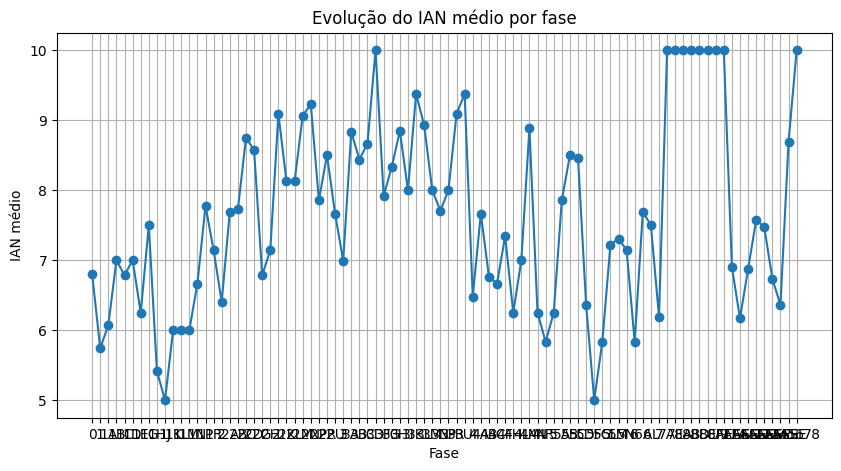

In [9]:
plt.figure(figsize=(10,5))
plt.plot(ian_por_fase.index, ian_por_fase.values, marker='o')
plt.title("Evolução do IAN médio por fase")
plt.xlabel("Fase")
plt.ylabel("IAN médio")
plt.grid()
plt.show()

In [10]:
print("\n Interpretação automática:")
if ian_por_fase.is_monotonic_increasing:
    print("O IAN apresenta melhora contínua ao longo das fases.")
elif ian_por_fase.is_monotonic_decreasing:
    print("O IAN apresenta piora contínua ao longo das fases.")
else:
    print("O IAN apresenta comportamento oscilatório ao longo das fases.")
if desvio > 2:
    print("Alta dispersão: há desigualdade relevante entre os alunos.")
else:
    print("Baixa dispersão: os alunos têm níveis semelhantes.")


 Interpretação automática:
O IAN apresenta comportamento oscilatório ao longo das fases.
Alta dispersão: há desigualdade relevante entre os alunos.


# 2.Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

In [11]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [12]:
col_ida = "IDA"
col_fase = "Fase"
col_ano = "Ano ingresso"

In [13]:
df = df[[col_ida, col_fase, col_ano]].dropna()

In [14]:
ida_por_fase = df.groupby(col_fase)[col_ida].mean().sort_index()
print("\n IDA médio por fase:")
print(ida_por_fase)


 IDA médio por fase:
Fase
0         7.140000
1         6.464062
1A        7.571429
1B        7.183333
1C        7.285714
            ...   
FASE 3    5.746970
FASE 4    6.004255
FASE 5    5.904615
FASE 6    6.809091
FASE 7    7.810000
Name: IDA, Length: 82, dtype: float64


In [15]:
ida_por_ano = df.groupby(col_ano)[col_ida].mean().sort_index()
print("\n IDA médio por ano:")
print(ida_por_ano)


 IDA médio por ano:
Ano ingresso
2016    5.950000
2017    6.082353
2018    5.835714
2019    6.028205
2020    6.589655
2021    6.412389
2022    6.293774
2023    6.685969
2024    6.455587
Name: IDA, dtype: float64


In [16]:
ida_fase_ano = df.groupby([col_ano, col_fase])[col_ida].mean().unstack()
print("\n IDA por fase e ano:")
print(ida_fase_ano)


 IDA por fase e ano:
Fase                 0         1        1A        1B       1C      1D     1E  \
Ano ingresso                                                                   
2016               NaN  5.100000       NaN       NaN      NaN     NaN    NaN   
2017               NaN  5.850000       NaN       NaN      NaN     NaN    NaN   
2018               NaN  6.437500       NaN       NaN      NaN     NaN    NaN   
2019          7.266667  6.338710       NaN       NaN      NaN     NaN    NaN   
2020          7.600000  6.988000       NaN       NaN      NaN     NaN    NaN   
2021          7.356410  6.902500       NaN  3.750000      NaN     NaN    NaN   
2022          7.061702  6.182353  6.500000  6.000000   5.9000  1.0000  6.250   
2023               NaN       NaN  8.055556  7.675000   7.8125  5.5000  4.875   
2024               NaN       NaN  6.750000  7.083333  10.0000  7.4375  6.900   

Fase              1G        1H        1J  ...        7E   8F      ALFA  \
Ano ingresso           

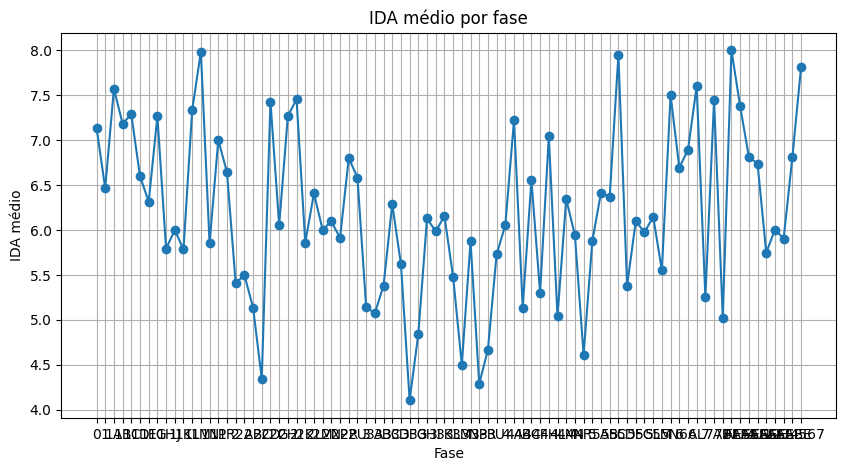

In [17]:
plt.figure(figsize=(10,5))
plt.plot(ida_por_fase.index, ida_por_fase.values, marker='o')
plt.title("IDA médio por fase")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.grid()
plt.show()

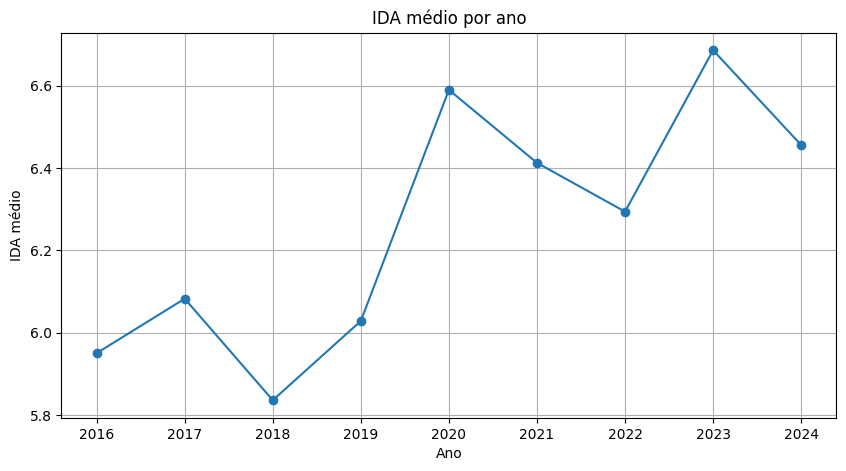

In [18]:
plt.figure(figsize=(10,5))
plt.plot(ida_por_ano.index, ida_por_ano.values, marker='o')
plt.title("IDA médio por ano")
plt.xlabel("Ano")
plt.ylabel("IDA médio")
plt.grid()
plt.show()

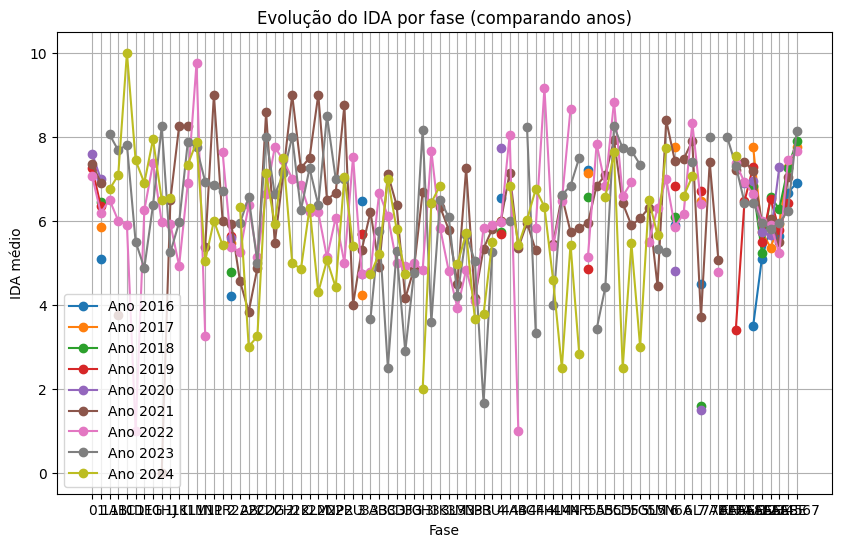

In [19]:
plt.figure(figsize=(10,6))
for ano in ida_fase_ano.index:
    plt.plot(ida_fase_ano.columns, ida_fase_ano.loc[ano], marker='o', label=f"Ano {ano}")
plt.title("Evolução do IDA por fase (comparando anos)")
plt.xlabel("Fase")
plt.ylabel("IDA médio")
plt.legend()
plt.grid()
plt.show()

In [20]:
x_fase = np.arange(len(ida_por_fase.index))
y_fase = ida_por_fase.values
coef_fase = np.polyfit(x_fase, y_fase, 1)[0]

In [21]:
x_ano = ida_por_ano.index.values
y_ano = ida_por_ano.values
coef_ano = np.polyfit(x_ano, y_ano, 1)[0]
print("\n Interpretação automática:")
if coef_fase > 0:
    print("O IDA melhora ao longo das fases.")
elif coef_fase < 0:
    print("O IDA piora ao longo das fases.")
else:
    print(" O IDA está estagnado nas fases.")
if coef_ano > 0:
    print("O desempenho melhora ao longo dos anos.")
elif coef_ano < 0:
    print("O desempenho está caindo ao longo dos anos.")
else:
  print("O desempenho está estagnado ao longo dos anos.")


 Interpretação automática:
O IDA piora ao longo das fases.
O desempenho melhora ao longo dos anos.


In [22]:
x_ano = ida_por_ano.index.values
y_ano = ida_por_ano.values
coef_ano = np.polyfit(x_ano, y_ano, 1)[0]
print("\n Interpretação automática:")
if coef_fase > 0:
    print("O IDA melhora ao longo das fases.")
elif coef_fase < 0:
    print("O IDA piora ao longo das fases.")
else:
    print(" O IDA está estagnado nas fases.")
if coef_ano > 0:
    print("O desempenho melhora ao longo dos anos.")
elif coef_ano < 0:
    print("O desempenho está caindo ao longo dos anos.")
else:
  print("O desempenho está estagnado ao longo dos anos.")


 Interpretação automática:
O IDA piora ao longo das fases.
O desempenho melhora ao longo dos anos.


#3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [23]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [24]:
col_ieg = "IEG"
col_ida = "IDA"
col_ipv = "IPV"

In [25]:
df = df[[col_ieg, col_ida, col_ipv]].dropna()

In [26]:
corr = df.corr()
print("\n Matriz de correlação:")
print(corr)
corr_ieg_ida = corr.loc[col_ieg, col_ida]
corr_ieg_ipv = corr.loc[col_ieg, col_ipv]
print("\nCorrelação IEG x IDA:", round(corr_ieg_ida, 3))
print("Correlação IEG x IPV:", round(corr_ieg_ipv, 3))


 Matriz de correlação:
          IEG       IDA       IPV
IEG  1.000000  0.543253  0.558282
IDA  0.543253  1.000000  0.557072
IPV  0.558282  0.557072  1.000000

Correlação IEG x IDA: 0.543
Correlação IEG x IPV: 0.558


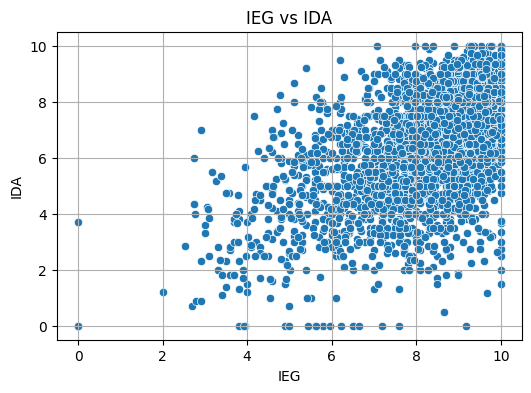

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x=col_ieg, y=col_ida)
plt.title("IEG vs IDA")
plt.grid()
plt.show()

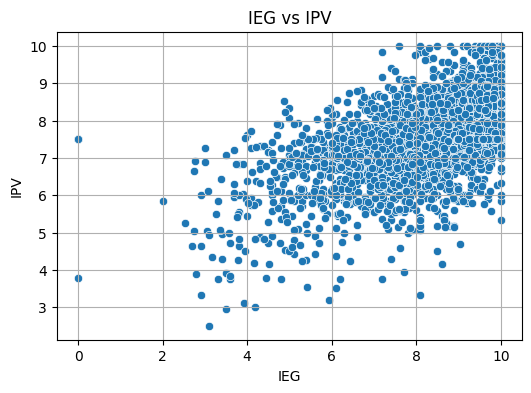

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x=col_ieg, y=col_ipv)
plt.title("IEG vs IPV")
plt.grid()
plt.show()

In [29]:
def interpreta_corr(valor):
    if abs(valor) >= 0.7:
        return "forte"
    elif abs(valor) >= 0.4:
        return "moderada"
    elif abs(valor) >= 0.2:
        return "fraca"
    else:
        return "muito fraca ou inexistente"
print("\n Interpretação:")
print(f"IEG x IDA: relação {interpreta_corr(corr_ieg_ida)} ({corr_ieg_ida:.2f})")
print(f"IEG x IPV: relação {interpreta_corr(corr_ieg_ipv)} ({corr_ieg_ipv:.2f})")
if corr_ieg_ida > 0:
    print("Quanto maior o engajamento, maior tende a ser o desempenho (IDA).")
else:
    print("Maior engajamento não está associado a melhor desempenho.")
if corr_ieg_ipv > 0:
    print("Engajamento também está associado ao ponto de virada (IPV).")
else:
    print("Engajamento não explica bem o ponto de virada.")


 Interpretação:
IEG x IDA: relação moderada (0.54)
IEG x IPV: relação moderada (0.56)
Quanto maior o engajamento, maior tende a ser o desempenho (IDA).
Engajamento também está associado ao ponto de virada (IPV).


#4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

In [30]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [31]:
col_iaa = "IAA"
col_ida = "IDA"
col_ieg = "IEG"

In [32]:
df = df[[col_iaa, col_ida, col_ieg]].dropna()

In [33]:
corr_iaa_ida = df[col_iaa].corr(df[col_ida])
corr_iaa_ieg = df[col_iaa].corr(df[col_ieg])
print("\n Correlações:")
print(f"IAA x IDA: {corr_iaa_ida:.3f}")
print(f"IAA x IEG: {corr_iaa_ieg:.3f}")


 Correlações:
IAA x IDA: 0.115
IAA x IEG: 0.131


In [34]:
df["gap_desempenho"] = df[col_iaa] - df[col_ida]
df["gap_engajamento"] = df[col_iaa] - df[col_ieg]
print("\n Estatísticas dos gaps:")
print(df[["gap_desempenho", "gap_engajamento"]].describe())


 Estatísticas dos gaps:
       gap_desempenho  gap_engajamento
count     2851.000000      2851.000000
mean         1.552776        -0.302761
std          3.080380         2.866882
min         -9.900000       -10.000000
25%          0.400000        -1.000000
50%          1.800000         0.000000
75%          3.400000         1.105198
max          9.600000         9.168000


In [35]:
def classificar(gap):
    if gap > 1:
        return "Superestima"
    elif gap < -1:
        return "Subestima"
    else:
        return "Realista"

df["perfil_percepcao"] = df["gap_desempenho"].apply(classificar)
print("\n Distribuição dos perfis:")
print(df["perfil_percepcao"].value_counts())


 Distribuição dos perfis:
perfil_percepcao
Superestima    1863
Realista        660
Subestima       328
Name: count, dtype: int64


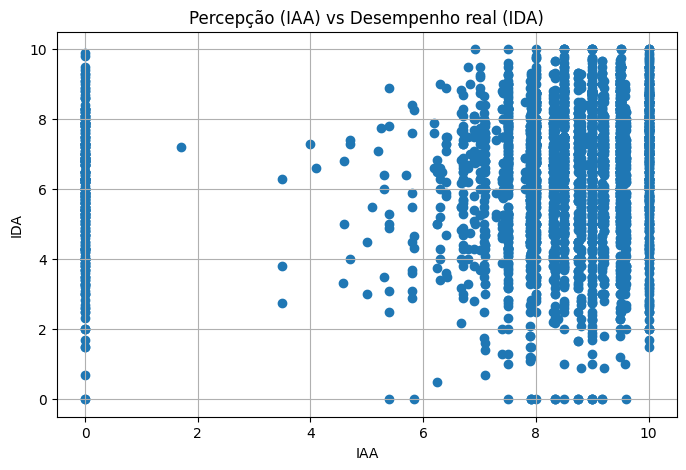

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(df[col_iaa], df[col_ida])
plt.title("Percepção (IAA) vs Desempenho real (IDA)")
plt.xlabel("IAA")
plt.ylabel("IDA")
plt.grid()
plt.show()

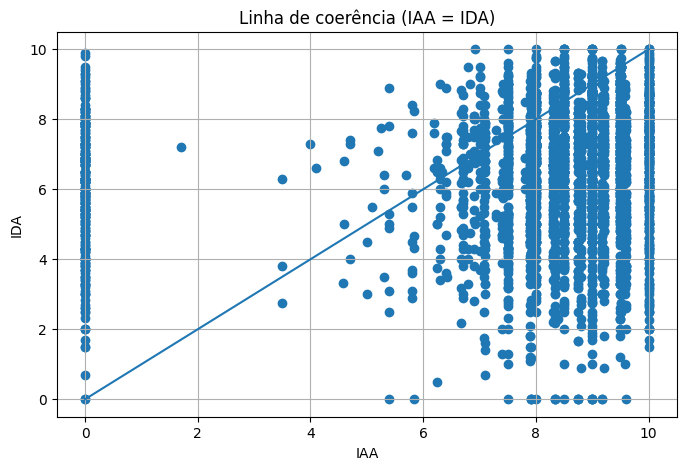

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(df[col_iaa], df[col_ida])
plt.plot([df[col_iaa].min(), df[col_iaa].max()],
         [df[col_iaa].min(), df[col_iaa].max()])
plt.title("Linha de coerência (IAA = IDA)")
plt.xlabel("IAA")
plt.ylabel("IDA")
plt.grid()
plt.show()

In [38]:
def interpretar_corr(valor):
    if abs(valor) < 0.3:
        return "fraca"
    elif abs(valor) < 0.6:
        return "moderada"
    else:
        return "forte"

print("\n Interpretação:")
print(f"A relação entre IAA e IDA é {interpretar_corr(corr_iaa_ida)}.")
print(f"A relação entre IAA e IEG é {interpretar_corr(corr_iaa_ieg)}.")


 Interpretação:
A relação entre IAA e IDA é fraca.
A relação entre IAA e IEG é fraca.


#5. Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [39]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [40]:
col_aluno = "RA"
col_fase = "Fase"
col_ida = "IDA"
col_ieg = "IEG"
col_ips = "IPS"

In [41]:
df = df[[col_aluno, col_fase, col_ida, col_ieg, col_ips]].dropna()

In [42]:
df = df.sort_values([col_aluno, col_fase])

In [43]:
df["delta_ida"] = df.groupby(col_aluno)[col_ida].diff()
df["delta_ieg"] = df.groupby(col_aluno)[col_ieg].diff()

In [44]:
df["queda_ida"] = df["delta_ida"] < 0
df["queda_ieg"] = df["delta_ieg"] < 0

In [45]:
df["ips_anterior"] = df.groupby(col_aluno)[col_ips].shift(1)

In [46]:
ips_queda_ida = df[df["queda_ida"] == True]["ips_anterior"]
ips_sem_queda_ida = df[df["queda_ida"] == False]["ips_anterior"]

In [47]:
ips_queda_ieg = df[df["queda_ieg"] == True]["ips_anterior"]
ips_sem_queda_ieg = df[df["queda_ieg"] == False]["ips_anterior"]

In [48]:
print("\n Comparação IPS (antes da queda de IDA):")
print("Queda:", ips_queda_ida.mean())
print("Sem queda:", ips_sem_queda_ida.mean())


 Comparação IPS (antes da queda de IDA):
Queda: 6.820894039735099
Sem queda: 6.800553435114504


In [49]:
print("\n Comparação IPS (antes da queda de IEG):")
print("Queda:", ips_queda_ieg.mean())
print("Sem queda:", ips_sem_queda_ieg.mean())


 Comparação IPS (antes da queda de IEG):
Queda: 6.8233379888268155
Sem queda: 6.80062326869806


/tmp/ipykernel_1811/1329792516.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ips_queda_ida.dropna(), ips_sem_queda_ida.dropna()],


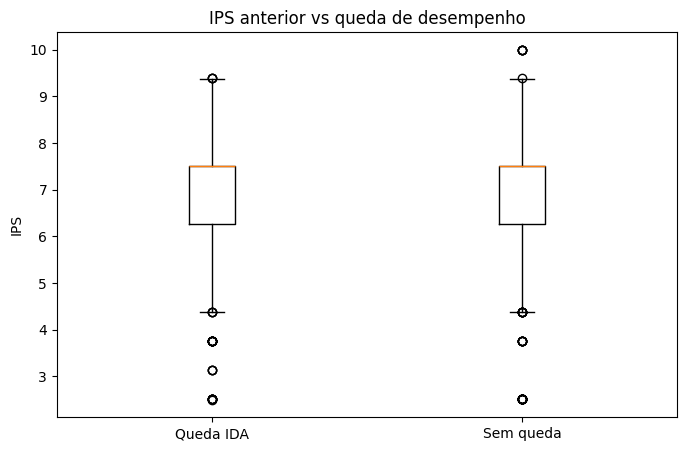

In [50]:
plt.figure(figsize=(8,5))
plt.boxplot([ips_queda_ida.dropna(), ips_sem_queda_ida.dropna()],
            labels=["Queda IDA", "Sem queda"])
plt.title("IPS anterior vs queda de desempenho")
plt.ylabel("IPS")
plt.show()

/tmp/ipykernel_1811/4888751.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ips_queda_ieg.dropna(), ips_sem_queda_ieg.dropna()],


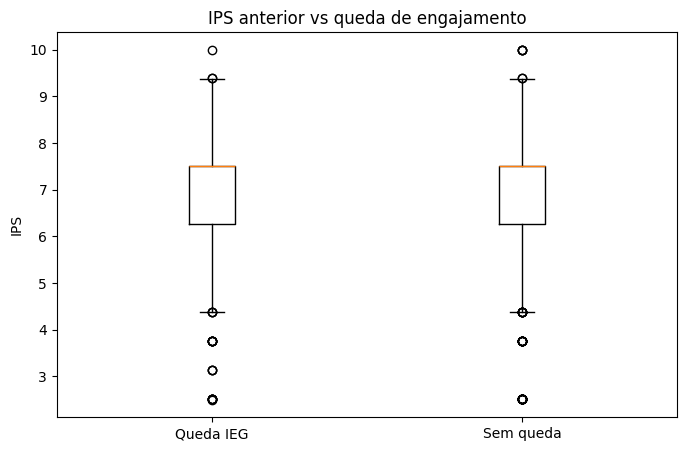

In [51]:
plt.figure(figsize=(8,5))
plt.boxplot([ips_queda_ieg.dropna(), ips_sem_queda_ieg.dropna()],
            labels=["Queda IEG", "Sem queda"])
plt.title("IPS anterior vs queda de engajamento")
plt.ylabel("IPS")
plt.show()

In [52]:
corr_ips_ida = df[col_ips].corr(df[col_ida])
corr_ips_ieg = df[col_ips].corr(df[col_ieg])
print("\n Correlações gerais:")
print(f"IPS x IDA: {corr_ips_ida:.3f}")
print(f"IPS x IEG: {corr_ips_ieg:.3f}")


 Correlações gerais:
IPS x IDA: 0.022
IPS x IEG: -0.047


#6. Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a
defasagem identificada pelo IAN?

In [53]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [54]:
col_ian = "IAN"
col_ipp = "IPP"

In [55]:
df = df[[col_ian, col_ipp]].dropna()

In [56]:
corr = df[col_ian].corr(df[col_ipp])
print("\n Correlação IAN x IPP:")
print(f"{corr:.3f}")


 Correlação IAN x IPP:
0.123


In [57]:
def classificar_ian(valor):
    if valor < 4:
        return "Alta defasagem"
    elif valor < 7:
        return "Defasagem moderada"
    else:
        return "Baixa defasagem"

df["grupo_ian"] = df[col_ian].apply(classificar_ian)

In [58]:
ipp_por_grupo = df.groupby("grupo_ian")[col_ipp].mean()
print("\n IPP médio por nível de defasagem:")
print(ipp_por_grupo)


 IPP médio por nível de defasagem:
grupo_ian
Alta defasagem        7.010417
Baixa defasagem       7.678196
Defasagem moderada    7.459217
Name: IPP, dtype: float64


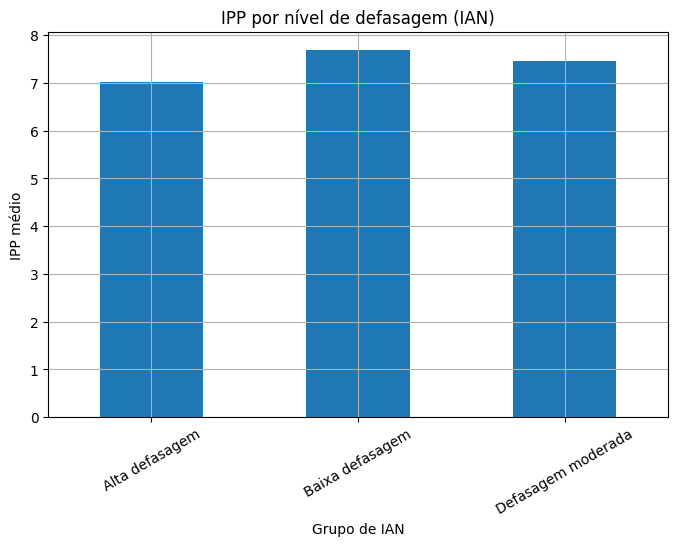

In [59]:
plt.figure(figsize=(8,5))
ipp_por_grupo.plot(kind="bar")
plt.title("IPP por nível de defasagem (IAN)")
plt.ylabel("IPP médio")
plt.xlabel("Grupo de IAN")
plt.xticks(rotation=30)
plt.grid()
plt.show()

In [60]:
df["ian_alto"] = df[col_ian] >= df[col_ian].median()
df["ipp_alto"] = df[col_ipp] >= df[col_ipp].median()
df["coerente"] = df["ian_alto"] == df["ipp_alto"]

taxa_coerencia = df["coerente"].mean()
print("\n Taxa de coerência:")
print(f"{taxa_coerencia:.2%}")


 Taxa de coerência:
65.71%


In [61]:
def interpretar_corr(valor):
    if abs(valor) < 0.3:
        return "fraca"
    elif abs(valor) < 0.6:
        return "moderada"
    else:
        return "forte"

print("\n Interpretação:")
print(f"A relação entre IAN e IPP é {interpretar_corr(corr)}.")
if taxa_coerencia > 0.7:
    print("Há forte consistência entre os indicadores.")
elif taxa_coerencia > 0.5:
    print("Há consistência moderada entre os indicadores.")
else:
    print("Há baixa consistência entre os indicadores.")


 Interpretação:
A relação entre IAN e IPP é fraca.
Há consistência moderada entre os indicadores.


#7. Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?

In [62]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [63]:
variaveis = [
    "IDA",  # acadêmico
    "IAN",  # defasagem
    "IAA",  # autoavaliação
    "IPS",  # psicossocial
    "IPP",  # psicopedagógico
    "IEG",  # engajamento
    "IPV"   # alvo
]
df = df[variaveis].dropna()

In [64]:
corrs = df.corr()["IPV"].sort_values(ascending=False)
print("\n Correlações com IPV:")
print(corrs)


 Correlações com IPV:
IPV    1.000000
IPP    0.606707
IEG    0.527240
IDA    0.519813
IAN    0.130677
IAA    0.022604
IPS   -0.063416
Name: IPV, dtype: float64


In [65]:
X = df.drop(columns=["IPV"])
y = df["IPV"]

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [67]:
modelo = LinearRegression()
modelo.fit(X_scaled, y)

LinearRegression()

In [68]:
coeficientes = pd.DataFrame({
    "Variável": X.columns,
    "Impacto": modelo.coef_
})

coeficientes = coeficientes.sort_values(
    by="Impacto",
    key=abs,
    ascending=False
)
print("\n Impacto das variáveis no IPV:")
print(coeficientes)


 Impacto das variáveis no IPV:
  Variável   Impacto
4      IPP  0.466564
5      IEG  0.276323
0      IDA  0.235371
3      IPS -0.087105
1      IAN  0.042240
2      IAA -0.038021


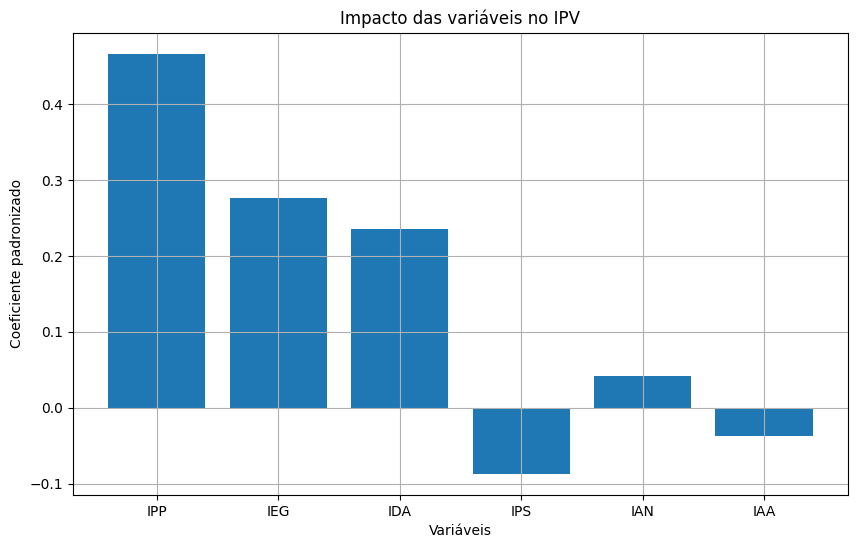

In [69]:
plt.figure(figsize=(10,6))
plt.bar(
    coeficientes["Variável"],
    coeficientes["Impacto"]
)
plt.title("Impacto das variáveis no IPV")
plt.xlabel("Variáveis")
plt.ylabel("Coeficiente padronizado")
plt.grid()
plt.show()

In [70]:
mais_importante = coeficientes.iloc[0]
print("\n Variável mais influente:")
print(f"{mais_importante['Variável']} "
      f"(impacto = {mais_importante['Impacto']:.3f})")


 Variável mais influente:
IPP (impacto = 0.467)


#8. Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais
a nota global do aluno (INDE)?

In [71]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [72]:
variaveis = [
    "IDA",
    "IEG",
    "IPS",
    "IPP",
    "INDE"
]
df = df[variaveis].dropna()

In [73]:
corrs = df.corr()["INDE"].sort_values(ascending=False)
print("\n Correlações com INDE:")
print(corrs)


 Correlações com INDE:
INDE    1.000000
IDA     0.766744
IEG     0.708827
IPP     0.540295
IPS     0.247743
Name: INDE, dtype: float64


In [74]:
def categorizar(coluna):
    return pd.qcut(coluna, q=3, labels=["Baixo", "Médio", "Alto"])
df["IDA_cat"] = categorizar(df["IDA"])
df["IEG_cat"] = categorizar(df["IEG"])
df["IPS_cat"] = categorizar(df["IPS"])
df["IPP_cat"] = categorizar(df["IPP"])

In [75]:
df["perfil"] = (
    "IDA_" + df["IDA_cat"].astype(str) + " | " +
    "IEG_" + df["IEG_cat"].astype(str) + " | " +
    "IPS_" + df["IPS_cat"].astype(str) + " | " +
    "IPP_" + df["IPP_cat"].astype(str)
)

In [76]:
ranking = (
    df.groupby("perfil")["INDE"]
    .mean()
    .sort_values(ascending=False)
)
print("\n Top combinações com maior INDE:")
print(ranking.head(10))


 Top combinações com maior INDE:
perfil
IDA_Alto | IEG_Alto | IPS_Alto | IPP_Alto      8.738516
IDA_Alto | IEG_Alto | IPS_Médio | IPP_Alto     8.626504
IDA_Alto | IEG_Alto | IPS_Alto | IPP_Médio     8.611161
IDA_Alto | IEG_Alto | IPS_Médio | IPP_Médio    8.386656
IDA_Alto | IEG_Médio | IPS_Alto | IPP_Alto     8.321855
IDA_Alto | IEG_Médio | IPS_Médio | IPP_Alto    8.302518
IDA_Alto | IEG_Alto | IPS_Alto | IPP_Baixo     8.296092
IDA_Médio | IEG_Alto | IPS_Médio | IPP_Alto    8.251135
IDA_Alto | IEG_Médio | IPS_Alto | IPP_Médio    8.243843
IDA_Médio | IEG_Alto | IPS_Alto | IPP_Alto     8.212363
Name: INDE, dtype: float64


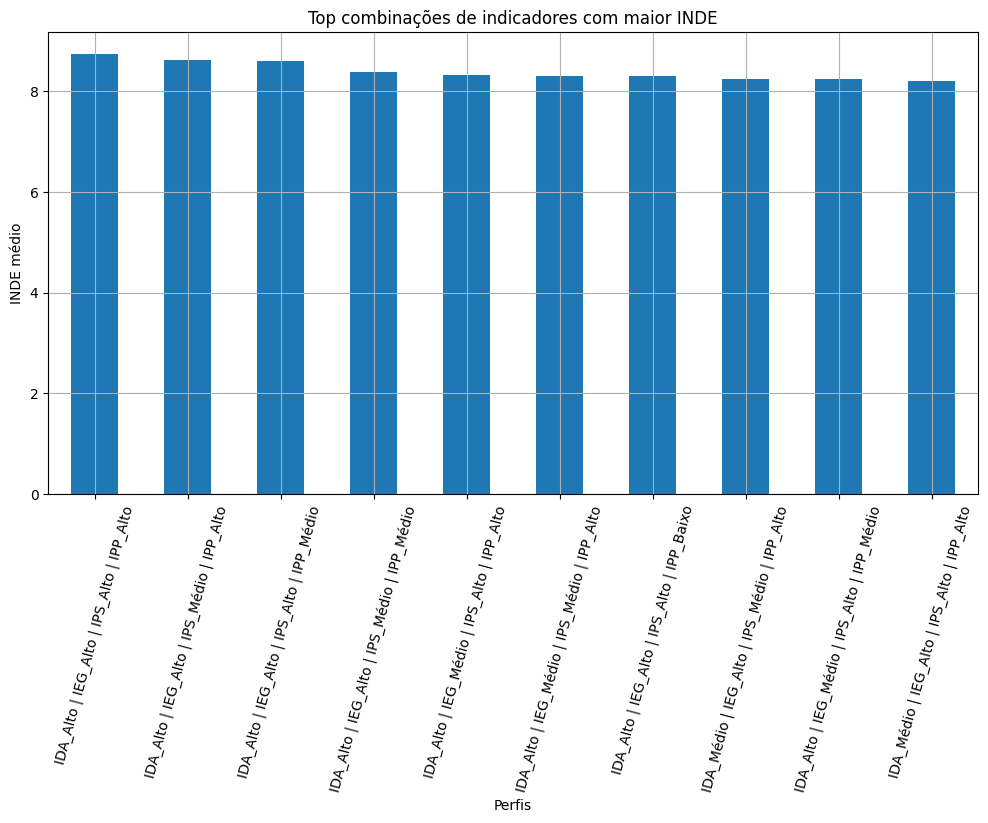

In [77]:
top10 = ranking.head(10)
plt.figure(figsize=(12,6))
top10.plot(kind="bar")
plt.title("Top combinações de indicadores com maior INDE")
plt.ylabel("INDE médio")
plt.xlabel("Perfis")
plt.xticks(rotation=75)
plt.grid()
plt.show()

In [78]:
melhor = ranking.idxmax()
valor = ranking.max()
print("\n Melhor combinação encontrada:")
print(melhor)
print(f"INDE médio: {valor:.2f}")


 Melhor combinação encontrada:
IDA_Alto | IEG_Alto | IPS_Alto | IPP_Alto
INDE médio: 8.74


#10. Efetividade do programa
Os indicadores mostram melhora consistente ao longo do ciclo nas
diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto
real do programa?

In [79]:
df = pd.read_csv("base_historico.csv")
print(df.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra', 'INDE',
       'Nº Av', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN',
       'Fase Ideal', 'Defasagem', 'Ano', 'Data de Nasc', 'IPP', 'Escola',
       'Ativo/ Inativo'],
      dtype='object')


In [80]:
fase_col = "Fase"
indicadores = [
    "IDA",
    "IEG",
    "IAN",
    "IPS",
    "IPP",
    "IPV",
    "INDE"
]

In [81]:
df = df[[fase_col] + indicadores].dropna()

In [82]:
medias_fase = df.groupby(fase_col)[indicadores].mean()
print("\n Médias dos indicadores por fase:")
print(medias_fase)


 Médias dos indicadores por fase:
             IDA       IEG       IAN       IPS       IPP       IPV      INDE
Fase                                                                        
1A      7.571429  8.883246  6.071429  6.840000  7.968750  7.912619  7.867619
1B      7.183333  8.663373  7.000000  6.340333  7.166667  7.413333  7.539541
1C      7.285714  9.242063  6.785714  7.420000  7.522321  7.721786  7.933031
1D      6.600000  8.476190  7.000000  7.260000  8.218750  7.793500  7.727013
1E      6.312500  7.913285  6.250000  6.885000  8.437500  7.698750  7.466307
...          ...       ...       ...       ...       ...       ...       ...
FASE 3  5.746970  8.439394  7.575758  4.670152  7.529593  7.575417  6.966130
FASE 4  6.023864  8.325000  7.613636  3.793750  7.824929  7.985199  7.072079
FASE 5  5.904615  8.453846  6.730769  4.346462  7.564904  7.451846  6.867291
FASE 6  6.809091  8.500000  6.363636  5.804242  7.807765  7.727803  7.243017
FASE 7  7.810000  9.170000  8.000000  6.0

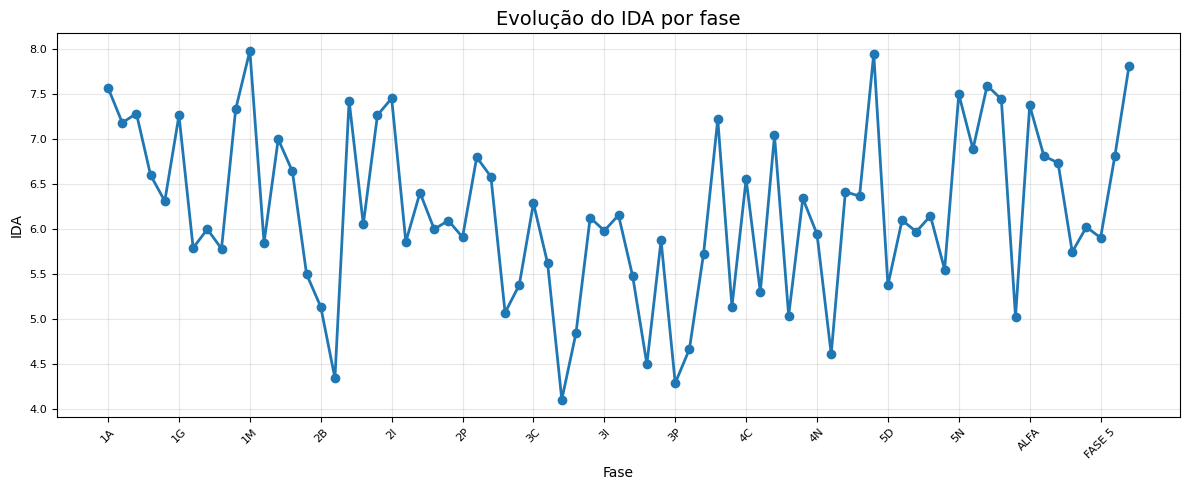

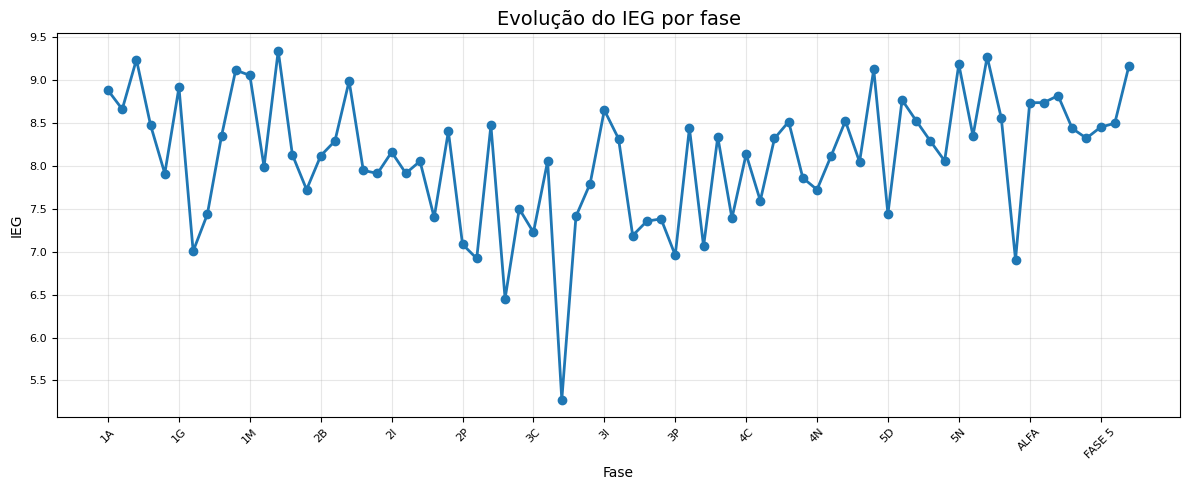

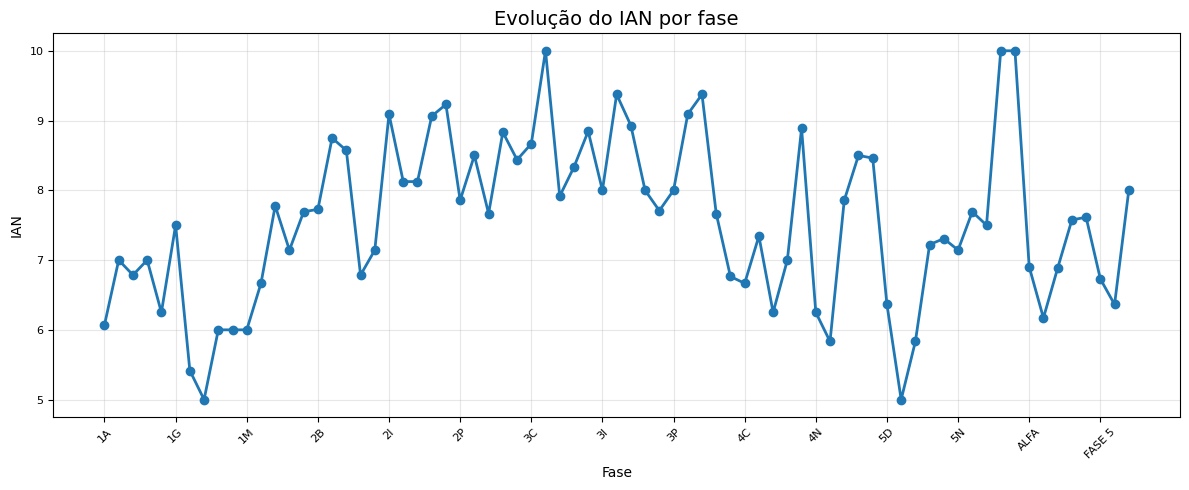

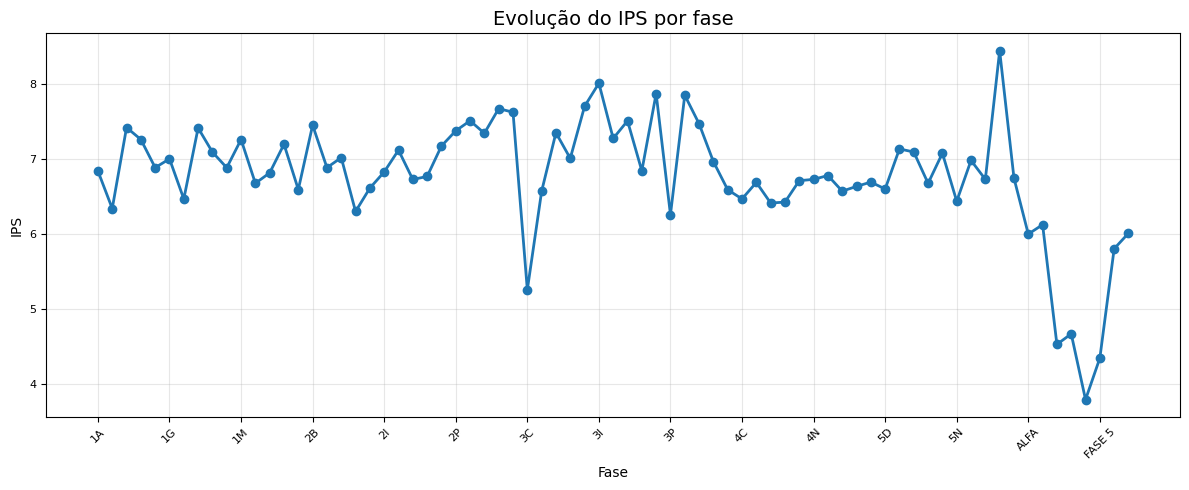

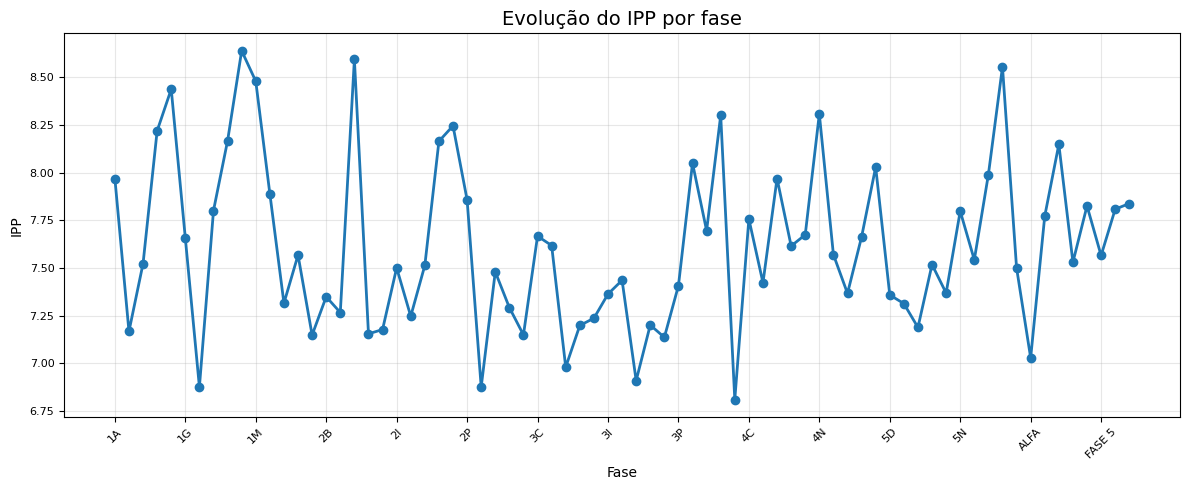

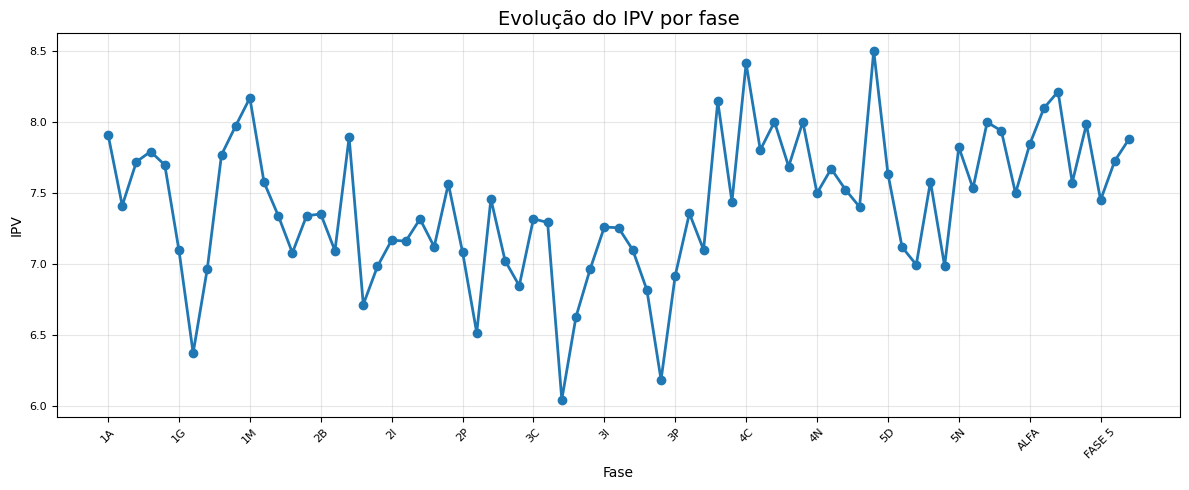

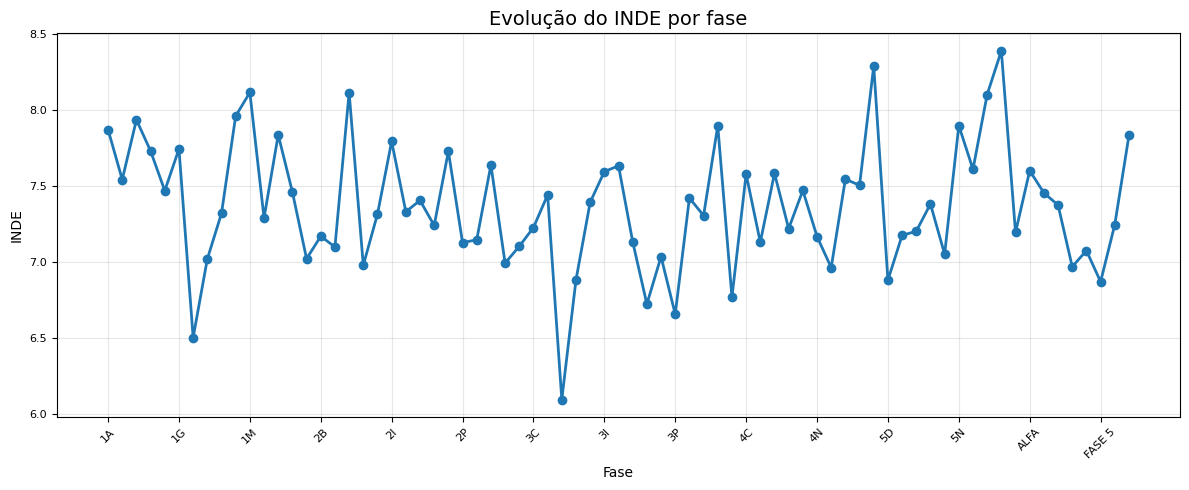

In [83]:
for indicador in indicadores:
    plt.figure(figsize=(12,5))

    plt.plot(
        medias_fase.index,
        medias_fase[indicador],
        marker='o',
        linewidth=2
    )
    plt.title(
        f"Evolução do {indicador} por fase",
        fontsize=14
    )
    plt.xlabel("Fase", fontsize=10)
    plt.ylabel(indicador, fontsize=10)

    plt.xticks(
        medias_fase.index[::5],
        rotation=45,
        fontsize=8
    )
    plt.yticks(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [84]:
print("\n Tendência dos indicadores:\n")
for indicador in indicadores:
    primeira = medias_fase[indicador].iloc[0]
    ultima = medias_fase[indicador].iloc[-1]
    variacao = ultima - primeira
    print(f"{indicador}:")

    if variacao > 0:
        print(f" Melhora geral (+{variacao:.2f})")
    elif variacao < 0:
        print(f" Queda geral ({variacao:.2f})")
    else:
        print(" Estável")
    print()


 Tendência dos indicadores:

IDA:
 Melhora geral (+0.24)

IEG:
 Melhora geral (+0.29)

IAN:
 Melhora geral (+1.93)

IPS:
 Queda geral (-0.83)

IPP:
 Queda geral (-0.13)

IPV:
 Queda geral (-0.03)

INDE:
 Queda geral (-0.04)



In [85]:
medias_fase["MEDIA_GERAL"] = medias_fase.mean(axis=1)
print("\n Índice médio consolidado por fase:")
print(medias_fase["MEDIA_GERAL"])


 Índice médio consolidado por fase:
Fase
1A        7.587870
1B        7.329512
1C        7.701519
1D        7.582208
1E        7.280477
            ...   
FASE 3    6.929059
FASE 4    6.948351
FASE 5    6.759962
FASE 6    7.179365
FASE 7    7.791306
Name: MEDIA_GERAL, Length: 73, dtype: float64


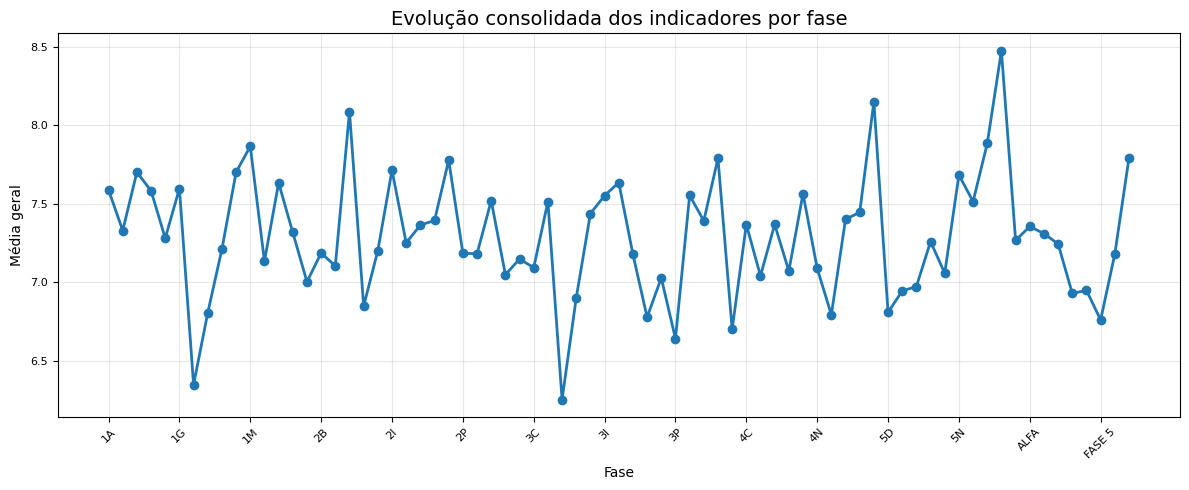

In [86]:
plt.figure(figsize=(12,5))
plt.plot(
    medias_fase.index,
    medias_fase["MEDIA_GERAL"],
    marker='o',
    linewidth=2
)
plt.title(
    "Evolução consolidada dos indicadores por fase",
    fontsize=14
)
plt.xlabel("Fase", fontsize=10)
plt.ylabel("Média geral", fontsize=10)
plt.xticks(
    medias_fase.index[::5],
    rotation=45,
    fontsize=8
)
plt.yticks(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()